## Title: Mobile Sales Analysis


This notebook provides an in-depth Exploratory Data Analysis (EDA) of the synthetic_mobile_sales_2025.csv dataset. The dataset simulates real-world mobile phone sales transactions across different brands, regions, and time periods in 2025. The analysis aims to uncover trends in brand popularity, revenue generation, pricing strategies, and customer purchasing behavior.

**Key Objectives**:
Identify the top-performing brands and models by revenue and units sold. 
Analyze regional sales distribution.
Determine the impact of pricing on sales volume. Evaluate seasonal trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/mobile-sales-data/synthetic_mobile_sales_2025.csv")
df

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,OnePlus,OnePlus Model 5,UK,128GB,Blue,371,10,3710,3.5,Debit Card,6,2025
496,497,Xiaomi,Xiaomi Model 4,Canada,128GB,Gold,414,8,3312,5.0,Installments,7,2025
497,498,Vivo,Vivo Model 9,Pakistan,256GB,Blue,314,17,5338,4.6,Cash,7,2025
498,499,Samsung,Samsung Model 19,France,128GB,Gold,342,1,342,4.5,Cash,6,2025


**Data Exploration**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sale_ID          500 non-null    int64  
 1   Brand            500 non-null    object 
 2   Model            500 non-null    object 
 3   Country          500 non-null    object 
 4   Storage          500 non-null    object 
 5   Color            500 non-null    object 
 6   Price_USD        500 non-null    int64  
 7   Units_Sold       500 non-null    int64  
 8   Revenue_USD      500 non-null    int64  
 9   Customer_Rating  500 non-null    float64
 10  Payment_Method   500 non-null    object 
 11  Sale_Month       500 non-null    int64  
 12  Sale_Year        500 non-null    int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 50.9+ KB


In [4]:
df.describe()

,Sale_ID,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Sale_Month,Sale_Year
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.0
mean,250.500000,889.88400,10.458000,9279.282000,4.022600,6.588000,2025.0
std,144.481833,345.61789,5.710118,6474.699423,0.582329,3.414905,0.0
min,1.000000,302.00000,1.000000,302.000000,3.000000,1.000000,2025.0
25%,125.750000,572.00000,6.000000,3959.250000,3.575000,4.000000,2025.0
50%,250.500000,896.50000,10.000000,8086.500000,4.000000,7.000000,2025.0
75%,375.250000,1173.75000,15.000000,13331.250000,4.500000,10.000000,2025.0
max,500.000000,1500.00000,20.000000,29660.000000,5.000000,12.000000,2025.0


In [5]:
df.columns

Index(['Sale_ID', 'Brand', 'Model', 'Country', 'Storage', 'Color', 'Price_USD',
       'Units_Sold', 'Revenue_USD', 'Customer_Rating', 'Payment_Method',
       'Sale_Month', 'Sale_Year'],
      dtype='object')

In [6]:
df.isnull()

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,False,False,False,False,False,False,False,False,False,False,False,False
496,False,False,False,False,False,False,False,False,False,False,False,False,False
497,False,False,False,False,False,False,False,False,False,False,False,False,False
498,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [8]:
df['Brand'].unique()

array(['Realme', 'Vivo', 'Motorola', 'Xiaomi', 'Huawei', 'Samsung',
       'OnePlus', 'Oppo', 'Apple', 'Google'], dtype=object)

In [9]:
# Change data type
df['Customer_Rating'].astype("int64")


0      3
1      3
2      3
3      3
4      4
      ..
495    3
496    5
497    4
498    4
499    3
Name: Customer_Rating, Length: 500, dtype: int64

In [10]:
df.shape

(500, 13)

In [11]:
df['Sale_Month'].astype(str)
df['Sale_Year'].astype(str)
df['Sale_Date'] = pd.to_datetime(df['Sale_Month'].astype(str)+ '-'+df['Sale_Year'].astype(str), format='%m-%Y')
df.head()
# Added a new column for date after changing type of month and year 

,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year,Sale_Date
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025,2025-11-01
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025,2025-02-01
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025,2025-02-01
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025,2025-06-01
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025,2025-01-01


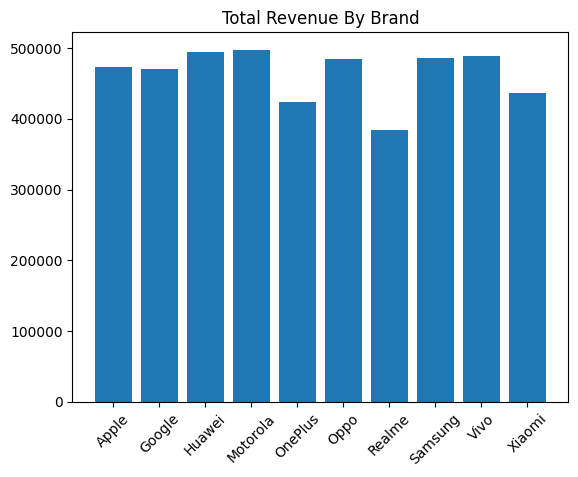

In [12]:
group_brand = df.groupby('Brand')['Revenue_USD'].sum().reset_index()
plt.bar(group_brand['Brand'], group_brand['Revenue_USD'])
plt.xticks(rotation=45)
plt.title("Total Revenue By Brand")
plt.show()
# Motorolla generated highest revenue. Realme generated lowest revenue 

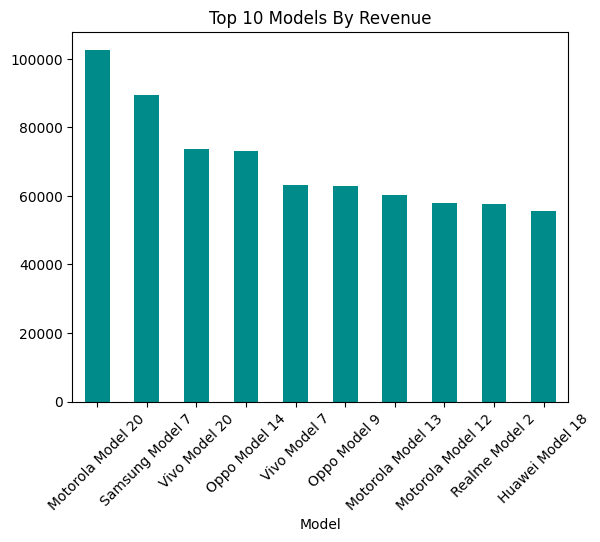

In [13]:
group_brand = df.groupby('Model')['Revenue_USD'].sum().sort_values(ascending = False).head(10)
group_brand.plot(kind = 'bar', color = 'darkcyan')
plt.xticks(rotation=45)
plt.title("Top 10 Models By Revenue")
plt.show()
# Motorola Model 20 is the to selling model

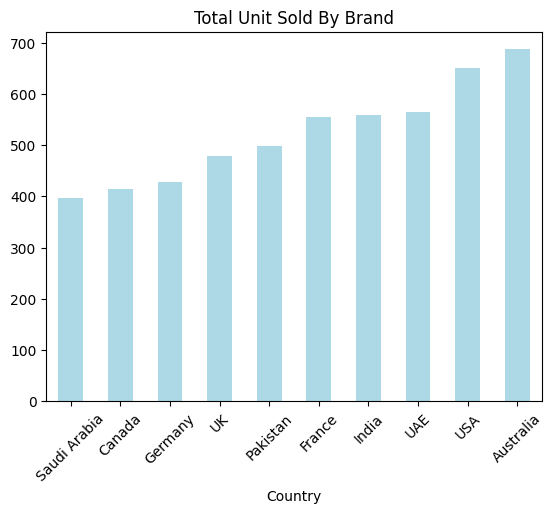

In [14]:
group_brand = df.groupby('Country')['Units_Sold'].sum().sort_values()
group_brand.plot(kind = 'bar', color = 'lightblue')
plt.xticks(rotation=45)
plt.title("Total Unit Sold By Brand")
plt.show()
# Australia has sold maximum units

In [15]:
df['Payment_Method'].nunique()

5

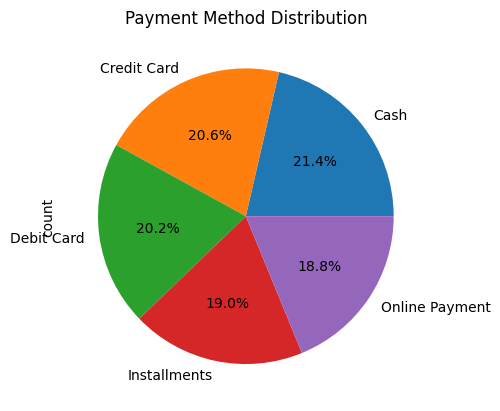

In [16]:
payment_counts = df["Payment_Method"].value_counts()
payment_counts.plot(kind='pie',autopct = '%1.1f%%', color = ['yelow','red','orange','pink','green'])
plt.title('Payment Method Distribution')
plt.show()
# Prefer to pay mostly by cash

In [17]:
#  Average price as per brand
Avg_Price= df.groupby("Brand")['Price_USD'].mean()
Avg_Price

Brand
Apple       943.437500
Google      872.423077
Huawei      941.240000
Motorola    883.818182
OnePlus     958.050000
Oppo        892.836735
Realme      759.061224
Samsung     943.705882
Vivo        869.913793
Xiaomi      849.375000
Name: Price_USD, dtype: float64

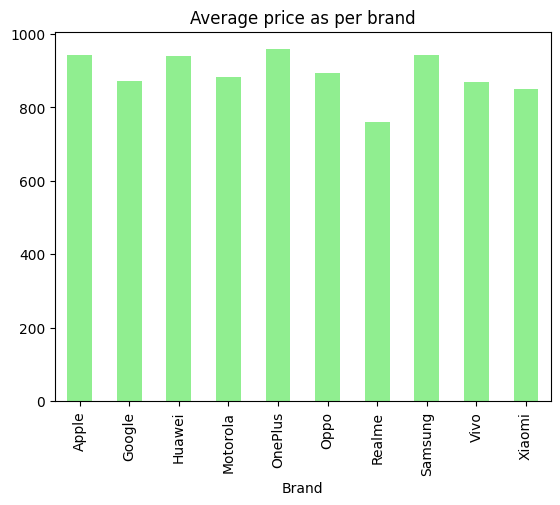

In [18]:
Avg_Price.plot(kind='bar', color='lightgreen')
plt.title("Average price as per brand")
plt.show()
# One plus has the highest average price

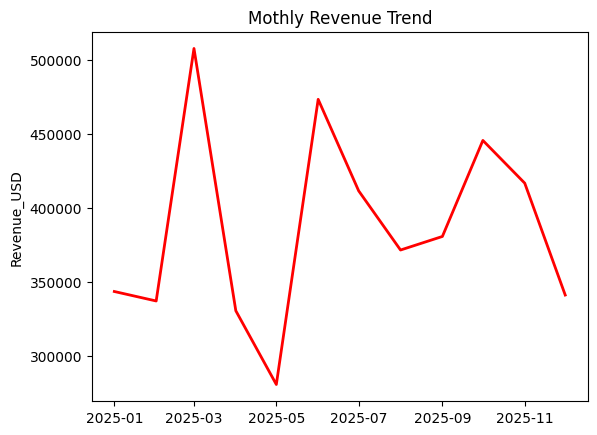

In [19]:
time_trend = df.groupby("Sale_Date")['Revenue_USD'].sum()
plt.plot(time_trend, color = 'red', linewidth = 2)
plt.title("Mothly Revenue Trend")
plt.ylabel("Revenue_USD")
plt.show()
# March has generated highest Revenue followed by June

In [20]:
df['date'] = pd.to_datetime(df['Sale_Date'])                # Convert to datetime
march_data = df[df['Sale_Date'].dt.month == 3]              # Filter March
top_10 = march_data.groupby('Model')['Revenue_USD'].sum().nlargest(10) # Get top 10
print(top_10)
#  Top 10 model contributed in March revenue (Highest revenue generated in the March)

Model
OnePlus Model 16    28860
Huawei Model 6      25630
Motorola Model 8    25460
Google Model 7      25313
OnePlus Model 1     23824
Vivo Model 12       21776
Xiaomi Model 3      20664
Apple Model 13      20464
Vivo Model 20       19650
Vivo Model 7        19566
Name: Revenue_USD, dtype: int64


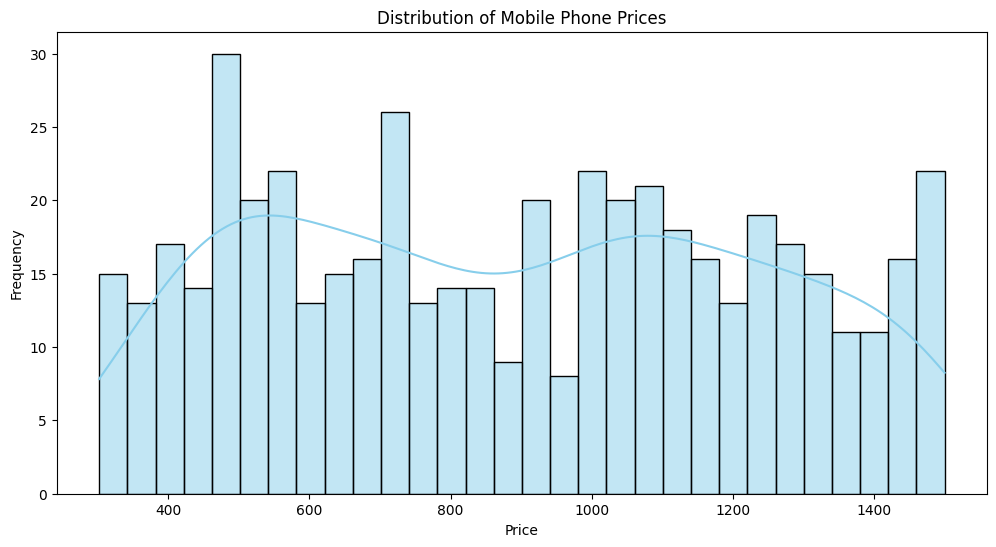

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Price_USD'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Mobile Phone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()
#The highest frequency of salesoccurs in the $400 to $800
#Spike Around $1000 to $1200 . The invenory stretches significantly into the luxury category above $1200

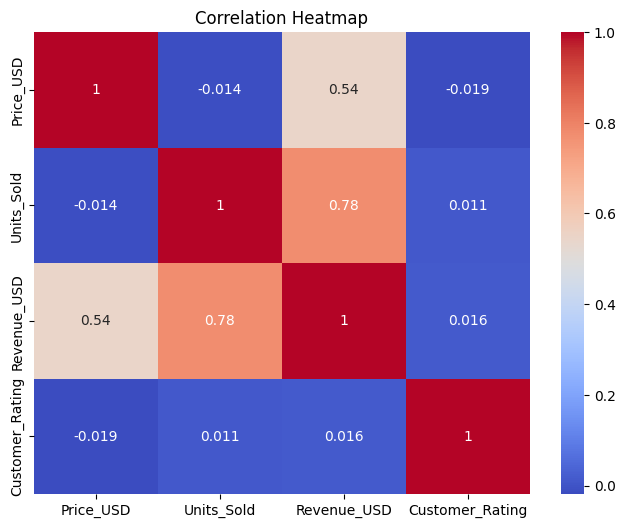

In [22]:
plt.figure(figsize=(8,6))
corr = df[['Price_USD','Units_Sold','Revenue_USD','Customer_Rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# Chart suggest that with the increase in price, no of unit sold decrease significatly
# Positive correlation Between unit sold and revenue generated
# Customer rating haing negatve correlation ie it is independent of all the metrics

**Key Insights & Findings**
**Brand Leadership**: Vivo leads in units sold, indicating high market penetration, while Motorola leads in revenue, suggesting a premium price strategy.

**Top Products**: The top 3 mobile models are Motorola Model 20, Samsung Model 7, Vivo Model 20 

**Regional Performance**: Australia contributes to the majority of the sales.

**Price Sensitivity**: A high volume of sales occurs within the $400- $800 and $1000-$1200 range, suggesting a competitive mid-range market.